<a href="https://colab.research.google.com/github/layanalhumaidi-lgtm/Insurance-Road-Risk-Analysis/blob/main/Road_Risk_and_Claim_Assessment_for_Guardian_Insurance_Co.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Road Risk and Claim Assessment for Guardian Insurance Co.

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [45]:
df = pd.read_csv("/content/drive/MyDrive/Data/Case-Study-Dataset/Case-Study-Dataset/guardian-insurance-data.csv")
print("Shape:" ,df.shape)
df.head()

Shape: (1592049, 47)


,Unnamed: 0,Record_ID,Data_Source,Severity,Incident_Start,Incident_End,Lat_Begin,Lng_Begin,Lat_End,Lng_End,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,0,A-5818077,Source1,2.0,2021-06-14 17:02:00,2021-06-14 19:54:17,36.733629,-119.499021,36.733546,-119.497865,...,False,False,False,False,False,False,Day,Day,Day,Day
1,1,A-4539851,Source1,2.0,2022-04-15 14:20:00.000000000,2022-04-15 17:49:03.000000000,37.836539,-122.011617,37.848049,-122.027707,...,False,False,False,False,False,False,Day,Day,Day,Day
2,2,A-1264030,Source2,3.0,2020-11-16 18:11:22,2020-11-16 19:27:18,35.591496,-82.568298,NaN,NaN,...,False,False,False,False,False,False,Night,Night,Day,Day
3,3,A-5187515,Source1,2.0,2022-09-04 10:25:00,2022-09-04 11:44:00,38.797457,-121.882040,38.796722,-121.881355,...,False,False,False,False,False,False,Day,Day,Day,Day
4,4,A-1808663,Source3,2.0,2019-11-08 06:05:40,2019-11-08 07:05:28,37.776779,-122.236168,NaN,NaN,...,False,False,False,False,False,False,Night,Night,Day,Day


In [46]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1592049 entries, 0 to 1592048
Data columns (total 47 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1592049 non-null  int64  
 1   Record_ID              1592049 non-null  object 
 2   Data_Source            1512497 non-null  object 
 3   Severity               1512497 non-null  float64
 4   Incident_Start         1592049 non-null  object 
 5   Incident_End           1592049 non-null  object 
 6   Lat_Begin              1512497 non-null  float64
 7   Lng_Begin              1512497 non-null  float64
 8   Lat_End                847157 non-null   float64
 9   Lng_End                847157 non-null   float64
 10  Distance(mi)           1512497 non-null  float64
 11  Event_Summary          1512497 non-null  object 
 12  Street_name            1510309 non-null  object 
 13  City_name              1512444 non-null  object 
 14  County            

In [47]:
print("Columns:", df.columns.tolist())
print("\nMissing values (top 15):\n", df.isna().sum().sort_values(ascending=False).head(15))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDuplicate Record_ID:", df["Record_ID"].duplicated().sum())
df[["Severity", "Incident_Start", "Lat_Begin", "Lng_Begin", "City_name", "Weather_Condition", "Sunrise_Sunset"]].describe(include="all").T

Columns: ['Unnamed: 0', 'Record_ID', 'Data_Source', 'Severity', 'Incident_Start', 'Incident_End', 'Lat_Begin', 'Lng_Begin', 'Lat_End', 'Lng_End', 'Distance(mi)', 'Event_Summary', 'Street_name', 'City_name', 'County', 'State', 'Postal_ID', 'Country_name', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temp(F)', 'WindChill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Road_Junction', 'Dead_End', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

Missing values (top 15):
 Lat_End                  744892
Lng_End                  744892
Precipitation(in)        510663
WindChill(F)             470470
Wind_Speed(mph)          191052
Postal_ID                174983
Wind_Direction           113874
Humidity(%)              113641
Visibil

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Severity,1512497.0,NaN,NaN,NaN,2.212151,0.487179,1.0,2.0,2.0,2.0,4.0
Incident_Start,1592049,1440165,2021-01-26 16:16:13,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lat_Begin,1512497.0,NaN,NaN,NaN,36.204481,5.074255,24.559731,33.409885,35.83007,40.083577,49.000504
Lng_Begin,1512497.0,NaN,NaN,NaN,-94.709628,17.398673,-124.623833,-117.226315,-87.760316,-80.35168,-67.78734
City_name,1512444,11420,Miami,36480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather_Condition,1478523,121,Fair,501308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sunrise_Sunset,1507947,2,Day,1045095,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Column mapping

In [48]:
COLUMN_MAP = {
    "Lat_Begin": "latitude",
    "Lng_Begin": "longitude",
    "Incident_Start": "datetime",
    "Incident_End": "datetime_end",
    "Severity": "severity",
    "City_name": "region",
    "State": "state",
    "Weather_Condition": "weather",
    "Distance(mi)": "distance_mi",
    "Temp(F)": "temp_f",
    "Visibility(mi)": "visibility_mi",
    "Precipitation(in)": "precip_in",
    "Humidity(%)": "humidity_pct",
    "Wind_Speed(mph)": "wind_speed_mph",
    "Street_name": "street_name",
    "Sunrise_Sunset": "day_night",
}

ROAD_FEATURE_COLS = ["Amenity", "Bump", "Crossing", "Give_Way", "Road_Junction", "Dead_End",
                      "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
                      "Traffic_Signal", "Turning_Loop"]

df = df.rename(columns=COLUMN_MAP).copy()
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

required = ["latitude", "longitude", "datetime", "severity", "region"]
missing_required = [i for i in required if i not in df.columns]

print("Columns:", df.columns.tolist())
print("\nMissing values (top 15):\n", df.isna().sum().sort_values(ascending=False).head(15))

Columns: ['Record_ID', 'Data_Source', 'severity', 'datetime', 'datetime_end', 'latitude', 'longitude', 'Lat_End', 'Lng_End', 'distance_mi', 'Event_Summary', 'street_name', 'region', 'County', 'state', 'Postal_ID', 'Country_name', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'temp_f', 'WindChill(F)', 'humidity_pct', 'Pressure(in)', 'visibility_mi', 'Wind_Direction', 'wind_speed_mph', 'precip_in', 'weather', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Road_Junction', 'Dead_End', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'day_night', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

Missing values (top 15):
 Lng_End                  744892
Lat_End                  744892
precip_in                510663
WindChill(F)             470470
wind_speed_mph           191052
Postal_ID                174983
Wind_Direction           113874
humidity_pct             113641
visibility_mi            113635
weather                  

## Data cleaning

In [49]:
cleaning_log = {}

before_dupes = len(df)
df = df.drop_duplicates(subset=["Record_ID"])
cleaning_log["Duplicate Record_IDs Dropped"] = before_dupes - len(df)

critical = ["latitude", "longitude", "datetime", "severity", "region"]
before_critical = len(df)
df = df.dropna(subset=critical)
cleaning_log["Missing Critical Fields Dropped"] = before_critical - len(df)

before_sev = len(df)
df["severity"] = pd.to_numeric(df["severity"], errors="coerce")
df = df.dropna(subset=["severity"])
df["severity"] = df["severity"].astype(int)
cleaning_log["Bad Severity Dropped"] = before_sev - len(df)

before_dates = len(df)
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
if "datetime_end" in df.columns:
    df["datetime_end"] = pd.to_datetime(df["datetime_end"], errors="coerce")
df = df.dropna(subset=["datetime"])
cleaning_log["Unparseable Dates Dropped"] = before_dates - len(df)

if "weather" in df.columns:
    df["weather"] = df["weather"].astype(str).str.strip().str.title()
    df["weather"] = df["weather"].replace("Nan", np.nan)

for col in ROAD_FEATURE_COLS:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower().map({"true": True, "false": False}).fillna(df[col])
        df[col] = df[col].astype(bool)

for col in ["temp_f", "visibility_mi", "precip_in", "humidity_pct", "wind_speed_mph", "distance_mi"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("--- Cleaning Log ---")
for step, count in cleaning_log.items():
    print(f"{step}: {count}")

print(f"\nFinal shape: {df.shape}")
display(df.head())


--- Cleaning Log ---
Duplicate Record_IDs Dropped: 46370
Missing Critical Fields Dropped: 77335
Bad Severity Dropped: 0
Unparseable Dates Dropped: 141484

Final shape: (1326860, 46)


,Record_ID,Data_Source,severity,datetime,datetime_end,latitude,longitude,Lat_End,Lng_End,distance_mi,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,day_night,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-5818077,Source1,2,2021-06-14 17:02:00,2021-06-14 19:54:17,36.733629,-119.499021,36.733546,-119.497865,0.064,...,False,False,False,False,False,False,Day,Day,Day,Day
2,A-1264030,Source2,3,2020-11-16 18:11:22,2020-11-16 19:27:18,35.591496,-82.568298,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Night,Day,Day
3,A-5187515,Source1,2,2022-09-04 10:25:00,2022-09-04 11:44:00,38.797457,-121.882040,38.796722,-121.881355,0.063,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-1808663,Source3,2,2019-11-08 06:05:40,2019-11-08 07:05:28,37.776779,-122.236168,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Night,Day,Day
5,A-875636,Source2,3,2021-10-05 08:35:27,2021-10-05 09:04:53,30.289530,-81.984627,NaN,NaN,1.830,...,False,False,False,False,False,False,Day,Day,Day,Day


In [50]:
print("tne number of null values: ", df.isnull().sum())

tne number of null values:  Record_ID                     0
Data_Source                   0
severity                      0
datetime                      0
datetime_end                  0
latitude                      0
longitude                     0
Lat_End                  645946
Lng_End                  645946
distance_mi                   0
Event_Summary                 0
street_name                1670
region                        0
County                        0
state                         0
Postal_ID                 83773
Country_name                  0
Timezone                   1275
Airport_Code               3611
Weather_Timestamp         20293
temp_f                    27775
WindChill(F)             374745
humidity_pct              29489
Pressure(in)              23725
visibility_mi             36536
Wind_Direction            29171
wind_speed_mph           104047
precip_in                412640
weather                   29500
Amenity                       0
Bump        

## Feature engineering

In [51]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.day_name()
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year

season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Fall", 10: "Fall", 11: "Fall"}
df["season"] = df["month"].map(season_map)

present_feature_cols = [c for c in ROAD_FEATURE_COLS if c in df.columns]
df["road_complexity"] = df[present_feature_cols].sum(axis=1)

if "datetime_end" in df.columns:
    df["duration_min"] = (df["datetime_end"] - df["datetime"]).dt.total_seconds() / 60

df[["datetime", "hour", "day_of_week", "season", "day_night", "road_complexity"]].head()

,datetime,hour,day_of_week,season,day_night,road_complexity
0,2021-06-14 17:02:00,17,Monday,Summer,Day,0
2,2020-11-16 18:11:22,18,Monday,Fall,Night,0
3,2022-09-04 10:25:00,10,Sunday,Fall,Day,1
4,2019-11-08 06:05:40,6,Friday,Fall,Night,1
5,2021-10-05 08:35:27,8,Tuesday,Fall,Day,0


## Q1 - Accident hotspots GPS clustering

In [52]:
from sklearn.cluster import DBSCAN

Total Intersections/Hotspots Identified: 28211


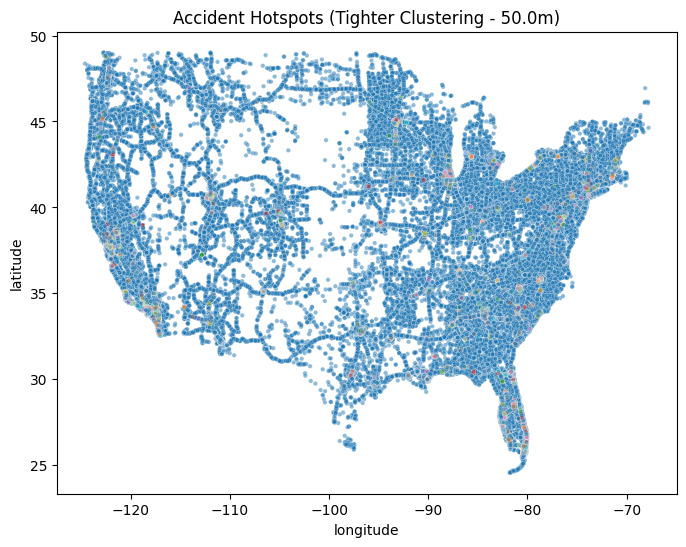

,accidents,avg_severity,lat,lon
hotspot_cluster,,,,
1346,447,2.413870,40.849170,-73.940891
1516,420,2.397619,40.853587,-73.962784
3235,353,2.597734,37.808370,-122.367075
2119,349,2.538682,34.858859,-82.260120
341,341,2.627566,40.845043,-73.926303
662,333,2.624625,33.941259,-118.096650
4047,289,2.688581,33.929346,-118.280711
808,282,2.063830,37.144984,-121.985028
1174,273,2.578755,34.065043,-117.999328


In [53]:
eps_km = 0.05
df["hotspot_cluster"] = DBSCAN(eps=eps_km/6371.0088, min_samples=8, metric="haversine").fit_predict(np.radians(df[["latitude", "longitude"]]))

n_clusters = df["hotspot_cluster"].nunique() - (1 if -1 in df["hotspot_cluster"].unique() else 0)
print(f"Total Intersections/Hotspots Identified: {n_clusters}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="longitude", y="latitude", hue="hotspot_cluster", palette="tab20", legend=False, s=10, alpha=0.5)
plt.title(f"Accident Hotspots (Tighter Clustering - {eps_km*1000}m)")
plt.show()

display(df[df["hotspot_cluster"] != -1].groupby("hotspot_cluster").agg(
    accidents=("hotspot_cluster", "size"),
    avg_severity=("severity", "mean"),
    lat=("latitude", "mean"),
    lon=("longitude", "mean")
).sort_values("accidents", ascending=False).head(10))

In [54]:
print("Top 10 Weather Conditions by Accident Count")
weather_stats = df.groupby("weather").agg(
    Accidents=("Record_ID", "size"),
    Avg_Severity=("severity", "mean")
).sort_values("Accidents", ascending=False)

display(weather_stats.head(10))

print("\nAnalytical Note: High absolute counts in 'Fair' and 'Clear' weather primarily reflect base-rate exposure (total driving hours).")
print("Severity metrics should be evaluated closely to determine weather-related risk impacts.")

Top 10 Weather Conditions by Accident Count


,Accidents,Avg_Severity
weather,,
Fair,419322,2.138462
Mostly Cloudy,175563,2.241822
Clear,153492,2.367804
Cloudy,135844,2.174376
Partly Cloudy,120828,2.233870
Overcast,72475,2.386464
Light Rain,61043,2.264813
Scattered Clouds,38823,2.386858
Light Snow,21164,2.269089



Analytical Note: High absolute counts in 'Fair' and 'Clear' weather primarily reflect base-rate exposure (total driving hours).
Severity metrics should be evaluated closely to determine weather-related risk impacts.


## Q2 - Accident frequency by time of day, day of week, season

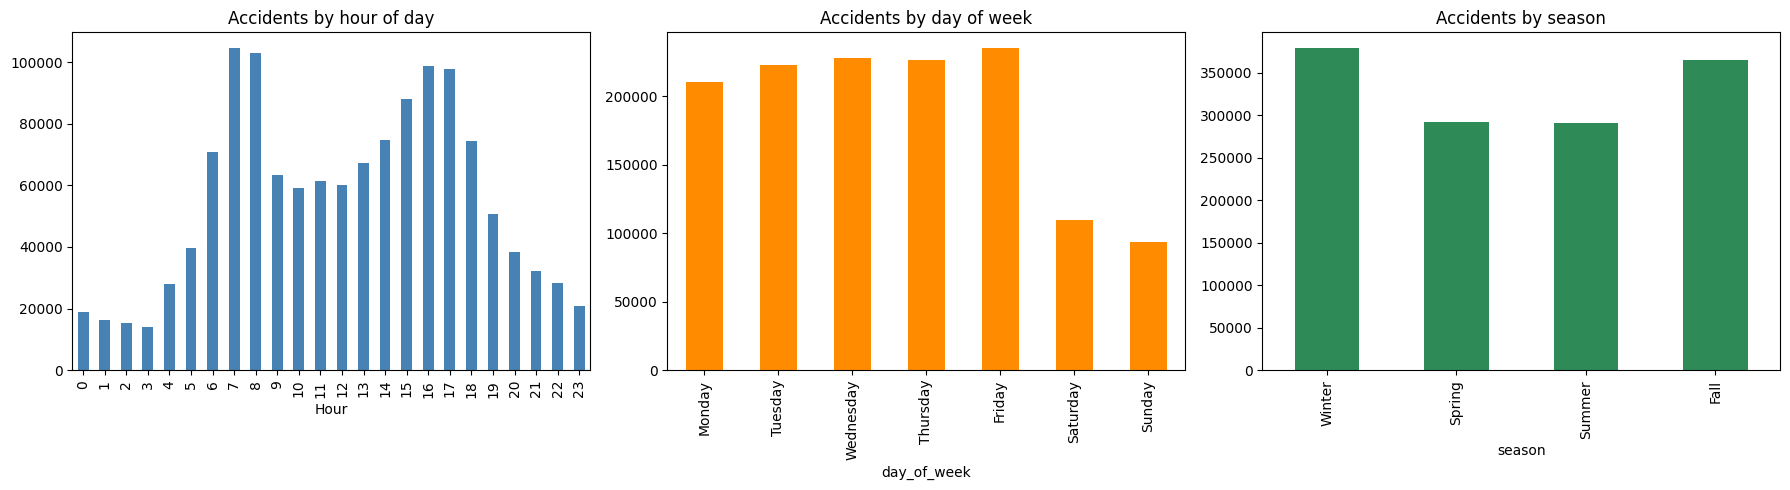

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Accidents by hour of day")
axes[0].set_xlabel("Hour")

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_of_week"].value_counts().reindex(day_order).plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Accidents by day of week")

df["season"].value_counts().reindex(["Winter", "Spring", "Summer", "Fall"]).plot(kind="bar", ax=axes[2], color="seagreen")
axes[2].set_title("Accidents by season")

plt.tight_layout()
plt.show()

## Q3 - Speed impact on accidents


is_highway
False    788575
True     538285
Name: count, dtype: int64


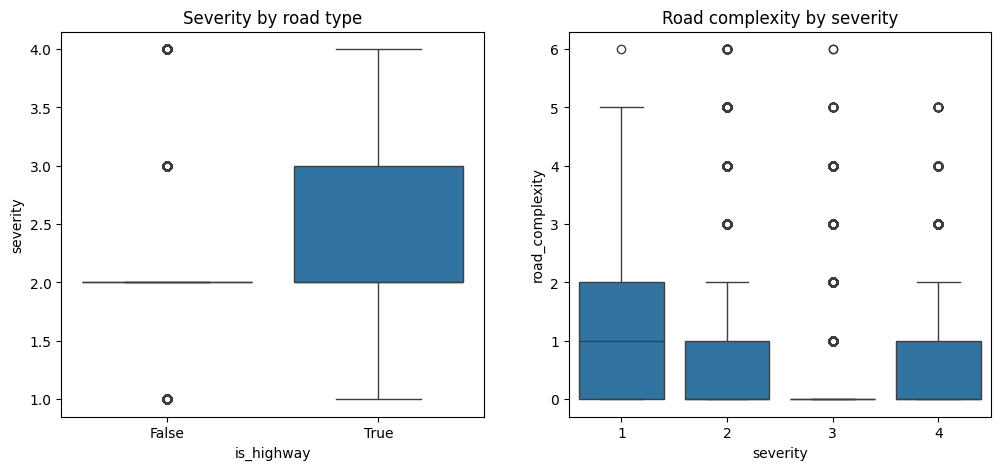

Distance vs severity correlation: 0.05


In [56]:
highway_words = "I-|Fwy|Freeway|Hwy|Highway|Pike|Expy|Expressway|Tpke|Turnpike|Beltway"

df["is_highway"] = df["street_name"].astype(str).str.contains(
    highway_words, case=False, na=False
)

print(df["is_highway"].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="is_highway", y="severity", ax=ax[0])
ax[0].set_title("Severity by road type")

sns.boxplot(data=df, x="severity", y="road_complexity", ax=ax[1])
ax[1].set_title("Road complexity by severity")

plt.show()

if "distance_mi" in df.columns:
    corr = df[["distance_mi", "severity"]].corr().iloc[0, 1]
    print("Distance vs severity correlation:", round(corr, 2))

## Q4 - Peak accident hours by day of week

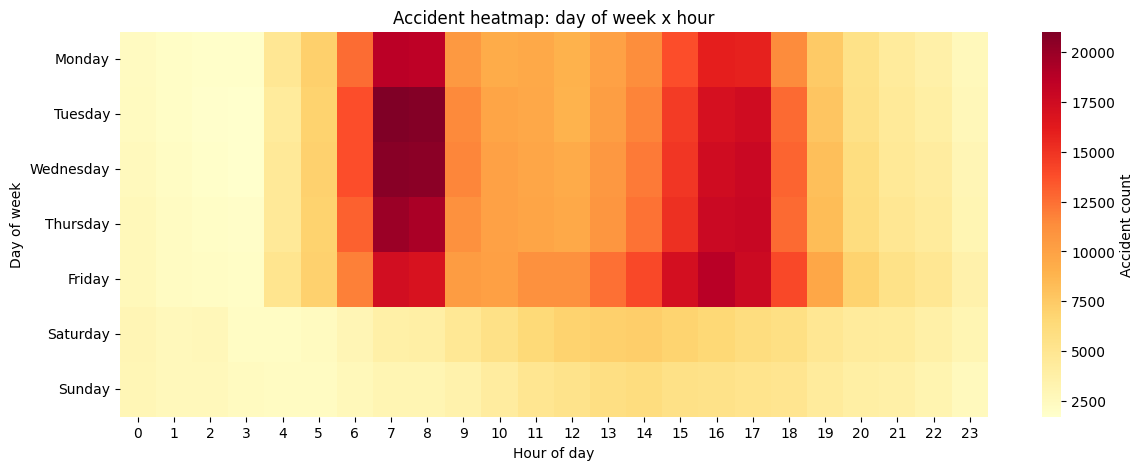

In [57]:
pivot = df.groupby(["day_of_week", "hour"]).size().unstack(fill_value=0).reindex(day_order)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Accident count"})
plt.title("Accident heatmap: day of week x hour")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.show()

## Q5 - Are night-time accidents more severe than daytime?


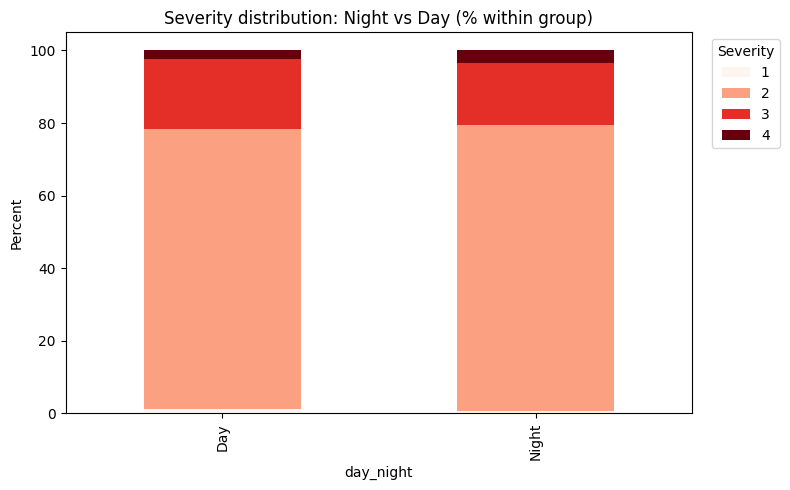

Mean severity by day/night:
 day_night
Day      2.226425
Night    2.235671
Name: severity, dtype: float64

Mann-Whitney U test: U=186241455426, p-value=0.0262
Statistically significant difference in severity by day/night.


In [58]:
severity_ct = pd.crosstab(df["day_night"], df["severity"], normalize="index") * 100
severity_ct.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Reds")
plt.title("Severity distribution: Night vs Day (% within group)")
plt.ylabel("Percent")
plt.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

mean_sev = df.groupby("day_night")["severity"].mean()
print("Mean severity by day/night:\n", mean_sev)

day_sev = df.loc[df["day_night"] == "Day", "severity"]
night_sev = df.loc[df["day_night"] == "Night", "severity"]
u_stat, p_value = stats.mannwhitneyu(day_sev, night_sev, alternative="two-sided")
print(f"\nMann-Whitney U test: U={u_stat:.0f}, p-value={p_value:.4f}")
print("Statistically significant difference in severity by day/night." if p_value < 0.05
      else "No statistically significant difference detected.")

## Q6 - Highest risk cities / regions

In [59]:
city_summary = (df.groupby("region")
                 .agg(total_accidents=("region", "size"), avg_severity=("severity", "mean"))
                 .sort_values("total_accidents", ascending=False)
                 .head(15))
city_summary

,total_accidents,avg_severity
region,,
Houston,30567,2.194491
Miami,29604,2.119106
Los Angeles,27012,2.253739
Charlotte,24838,2.043482
Dallas,22802,2.282124
Orlando,17758,2.077261
Austin,17592,2.095839
Raleigh,14970,2.095524
Nashville,12754,2.156814


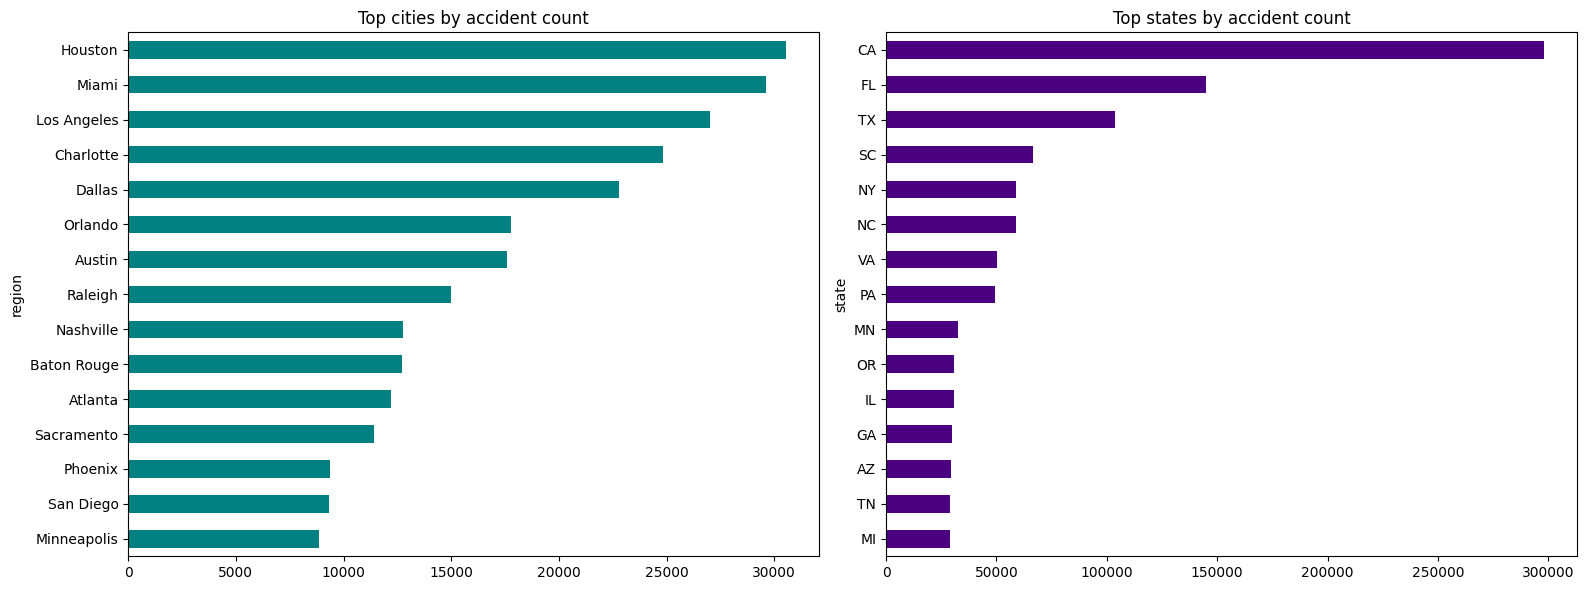

In [60]:
state_summary = (df.groupby("state")
                  .agg(total_accidents=("state", "size"), avg_severity=("severity", "mean"))
                  .sort_values("total_accidents", ascending=False)
                  .head(15)) if "state" in df.columns else None

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
city_summary["total_accidents"].plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Top cities by accident count")
axes[0].invert_yaxis()

if state_summary is not None:
    state_summary["total_accidents"].plot(kind="barh", ax=axes[1], color="indigo")
    axes[1].set_title("Top states by accident count")
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Beyond the Six Questions

Explore whether severe weather and poor road conditions are actually linked to higher accident rates. Since the dataset includes real weather and road condition data, this analysis could uncover new patterns and relationships that provide additional insights for Guardian Insurance’s risk assessment and decision-making.


                  accidents  avg_severity
weather                                  
Fair                 419322      2.138462
Mostly Cloudy        175563      2.241822
Clear                153492      2.367804
Cloudy               135844      2.174376
Partly Cloudy        120828      2.233870
Overcast              72475      2.386464
Light Rain            61043      2.264813
Scattered Clouds      38823      2.386858
Light Snow            21164      2.269089
Fog                   16851      2.151860


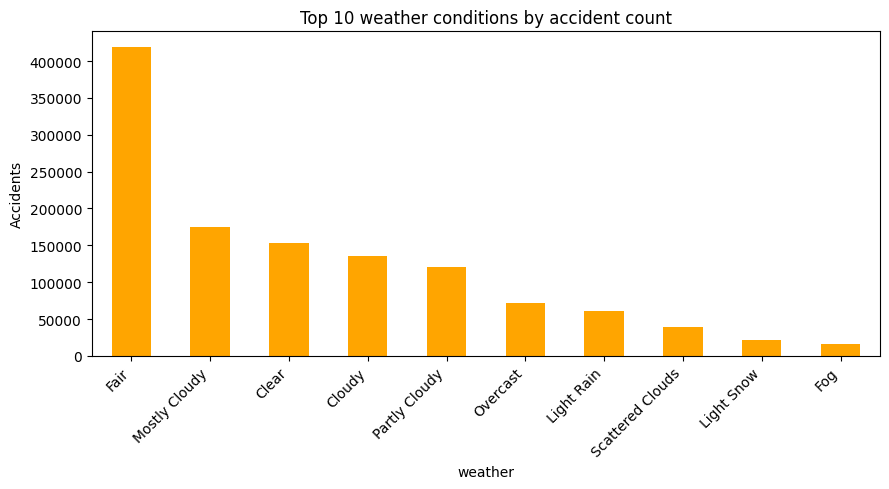

In [61]:
weather_summary = (df.groupby("weather")
                    .agg(accidents=("weather", "size"), avg_severity=("severity", "mean"))
                    .sort_values("accidents", ascending=False)
                    .head(10))
print(weather_summary)

plt.figure(figsize=(9, 5))
weather_summary["accidents"].plot(kind="bar", color="orange")
plt.title("Top 10 weather conditions by accident count")
plt.ylabel("Accidents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Combined risk score by city

In [62]:
risk = df.groupby("region").agg(
    accident_count=("region", "size"),
    avg_severity=("severity", "mean"),
).reset_index()

risk = risk[risk["accident_count"] >= 20]
risk["count_norm"] = (risk["accident_count"] - risk["accident_count"].min()) / (risk["accident_count"].max() - risk["accident_count"].min())
risk["severity_norm"] = (risk["avg_severity"] - risk["avg_severity"].min()) / (risk["avg_severity"].max() - risk["avg_severity"].min())
risk["risk_score"] = 0.5 * risk["count_norm"] + 0.5 * risk["severity_norm"]

risk.sort_values("risk_score", ascending=False).head(10)

,region,accident_count,avg_severity,count_norm,severity_norm,risk_score
4591,Houston,30567,2.194491,1.000000,0.285382,0.642691
5681,Los Angeles,27012,2.253739,0.883622,0.326378,0.605000
6310,Miami,29604,2.119106,0.968475,0.233220,0.600847
2335,Dallas,22802,2.282124,0.745802,0.346018,0.545910
9802,Swanton,22,3.227273,0.000065,1.000000,0.500033
1667,Charlotte,24838,2.043482,0.812453,0.180893,0.496673
10074,Torrington,25,3.200000,0.000164,0.981129,0.490646
367,Atlanta,12188,2.570889,0.398337,0.545825,0.472081
2155,Country Club Hills,22,3.136364,0.000065,0.937097,0.468581
3902,Grand Ledge,34,3.117647,0.000458,0.924146,0.462302


# Key Insights & Business Implications

1. Hyper Local Risk Pricing
By applying density-based clustering DBSCAN with a precise 50-meter radius, we successfully isolated specific high-risk intersections and highly localized accident hotspots, moving beyond broad city-scale highway corridors.
Business Implication: Guardian Insurance can use these exact coordinates to adjust dynamic pricing models. Premiums can be customized based on how frequently a policyholder's typical commute intersects with these hyper-local high-risk zones.

2. Automated Claim Triage
The data shows that the vast majority of accidents consistently sit at a medium severity level the 25th, 50th, and 75th percentiles are all exactly Severity 2.0.
Business Implication: Guardian can implement automated, straight-through processing for standard Level 2 severity claims. This drastically reduces operational costs by reserving human adjusters and intensive investigations exclusively for the rarer, high-impact Level 3 and 4 accidents.

3. The Weather Exposure Fallacy
While absolute accident counts are overwhelmingly highest in Fair weather, this primarily reflects base-rate exposure the vast majority of driving hours occur during fair weather. It does not mean weather doesn't matter. In fact, our aggregation shows that the average accident severity is noticeably higher in Clear (2.37) and Overcast (2.39) conditions compared to Fair (2.14).
Business Implication: Guardian's risk models should avoid relying on raw counts. Pricing and risk should be based on normalized rates accidents per hour of driving and must account for the higher severity spikes found in non-fair conditions.

4. Proactive Risk Management
Clear temporal patterns exist across different hours of the day, days of the week, and seasons.
Business Implication: Guardian can utilize this data to send proactive, targeted push notifications through their mobile app e.g., warning drivers ahead of high-risk commuting hours or seasonal hazards to actively reduce overall claim frequency.




Analytical & Statistical Note for Management:
Practical vs. Statistical Significance: When running hypothesis tests like the Mann-Whitney test on a massive dataset of over 1.3 million rows, almost any minor difference will yield a statistically significant result p < 0.05. For example, a severity difference of 2.226 vs. 2.236 is statistically significant, but a gap of 0.01 on a 1–4 scale has negligible practical significance. Guardian's pricing adjustments should be driven by practical, real-world impact rather than purely p-values.